First 5 Records:
        City        Date  PM2.5  PM10     NO    NO2    NOx  NH3     CO    SO2  \
0  Ahmedabad  2015-01-01    NaN   NaN   0.92  18.22  17.15  NaN   0.92  27.64   
1  Ahmedabad  2015-01-02    NaN   NaN   0.97  15.69  16.46  NaN   0.97  24.55   
2  Ahmedabad  2015-01-03    NaN   NaN  17.40  19.30  29.70  NaN  17.40  29.07   
3  Ahmedabad  2015-01-04    NaN   NaN   1.70  18.48  17.97  NaN   1.70  18.59   
4  Ahmedabad  2015-01-05    NaN   NaN  22.10  21.42  37.76  NaN  22.10  39.33   

       O3  Benzene  Toluene  Xylene  AQI AQI_Bucket  
0  133.36     0.00     0.02    0.00  NaN        NaN  
1   34.06     3.68     5.50    3.77  NaN        NaN  
2   30.70     6.80    16.40    2.25  NaN        NaN  
3   36.08     4.43    10.14    1.00  NaN        NaN  
4   39.31     7.01    18.89    2.78  NaN        NaN  

Dataset Shape:
(29531, 16)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column  

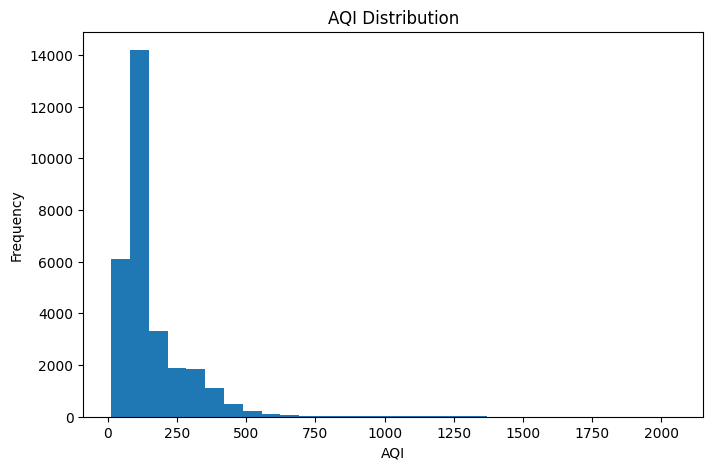

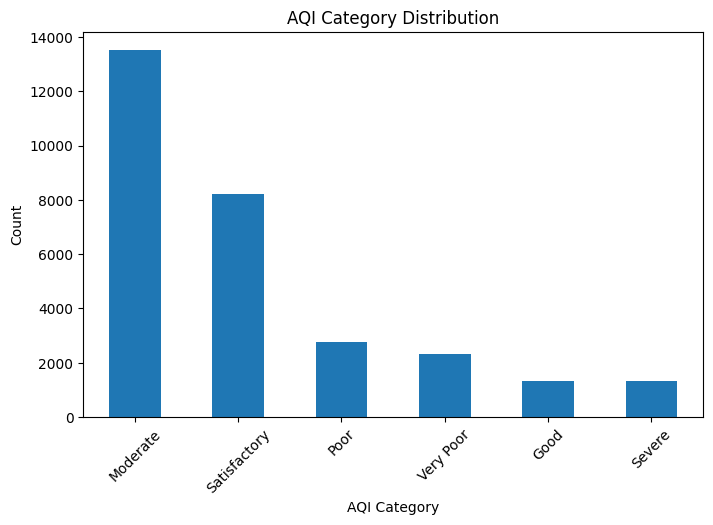

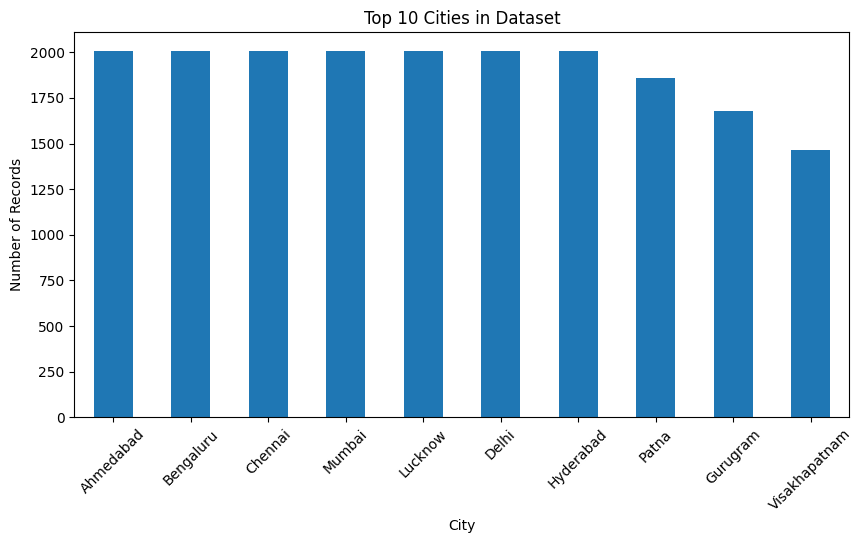

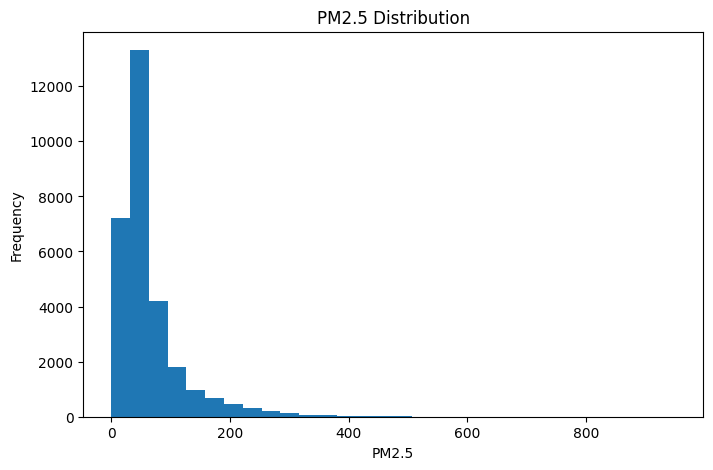

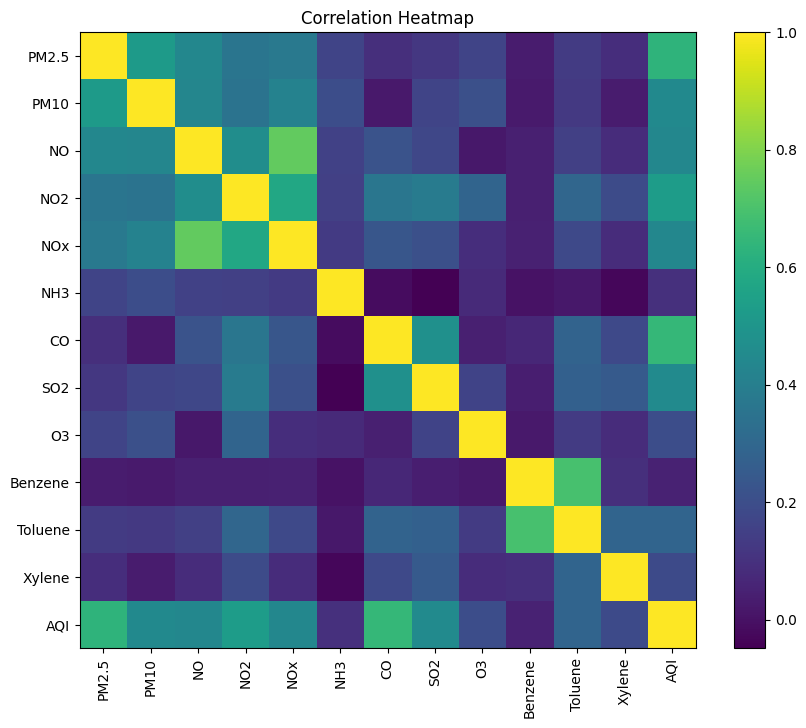


AQI Analysis
Average AQI = 158.78155158985473
Maximum AQI = 2049.0
Minimum AQI = 13.0

Most Common AQI Category:
Moderate

CRISP-DM: Data understanding, preparation, modeling and evaluation completed.
SEMMA: Sample, Explore, Modify, Model and Assess completed.
KDD: Selection, Preprocessing, Transformation, Data Mining and Interpretation completed.

Air quality patterns and trends identified successfully.


In [15]:
# ============================================================
# EXPERIMENT 1.B - EDA AND DATA CLEANING
# CITY DAY AIR QUALITY DATASET
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. LOAD DATASET
# ------------------------------------------------------------

df = pd.read_csv("city_day.csv")

print("First 5 Records:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
print(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Records:")
print(df.duplicated().sum())


# ------------------------------------------------------------
# 2. DATA CLEANING
# ------------------------------------------------------------

# Remove duplicate records
df.drop_duplicates(inplace=True)

# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Fill numerical missing values with median
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Fill categorical missing values with mode
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

print("\nDataset Shape After Cleaning:")
print(df.shape)


# ------------------------------------------------------------
# 3. EDA - AQI DISTRIBUTION
# ------------------------------------------------------------

plt.figure(figsize=(8,5))
plt.hist(df['AQI'], bins=30)
plt.title("AQI Distribution")
plt.xlabel("AQI")
plt.ylabel("Frequency")
plt.show()


# ------------------------------------------------------------
# 4. AQI CATEGORY DISTRIBUTION
# ------------------------------------------------------------

plt.figure(figsize=(8,5))
df['AQI_Bucket'].value_counts().plot(kind='bar')
plt.title("AQI Category Distribution")
plt.xlabel("AQI Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


# ------------------------------------------------------------
# 5. TOP 10 CITIES
# ------------------------------------------------------------

plt.figure(figsize=(10,5))

df['City'].value_counts().head(10).plot(kind='bar')

plt.title("Top 10 Cities in Dataset")
plt.xlabel("City")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)
plt.show()


# ------------------------------------------------------------
# 6. PM2.5 DISTRIBUTION
# ------------------------------------------------------------

plt.figure(figsize=(8,5))

plt.hist(df['PM2.5'], bins=30)

plt.title("PM2.5 Distribution")
plt.xlabel("PM2.5")
plt.ylabel("Frequency")
plt.show()


# ------------------------------------------------------------
# 7. CORRELATION HEATMAP
# ------------------------------------------------------------

corr = df.select_dtypes(include='number').corr()

plt.figure(figsize=(10,8))

plt.imshow(corr)
plt.colorbar()

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.title("Correlation Heatmap")
plt.show()


# ------------------------------------------------------------
# 8. BASIC AQI ANALYSIS
# ------------------------------------------------------------

print("\nAQI Analysis")

print("Average AQI =", df['AQI'].mean())
print("Maximum AQI =", df['AQI'].max())
print("Minimum AQI =", df['AQI'].min())

print("\nMost Common AQI Category:")
print(df['AQI_Bucket'].mode()[0])


# ------------------------------------------------------------
# 9. FRAMEWORK SUMMARY
# ------------------------------------------------------------

print("\nCRISP-DM: Data understanding, preparation, modeling and evaluation completed.")
print("SEMMA: Sample, Explore, Modify, Model and Assess completed.")
print("KDD: Selection, Preprocessing, Transformation, Data Mining and Interpretation completed.")

print("\nAir quality patterns and trends identified successfully.")